# 02 — Crop Model

Trains a YOLOv8n model to detect the card boundary (`crn` or `nid`) in a raw
photo, then crops it out. This is step 1 of the pipeline: every downstream
step (field detection, OCR) runs on the *cropped* card, not the raw photo.

In [ ]:
!pip install ultralytics -q

In [ ]:
from ultralytics import YOLO

model_crop = YOLO('yolov8n.pt')

results_crop = model_crop.train(
    data='/kaggle/working/crop-data/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='crop_model'
)

In [1]:
# Best weights location after training
print(results_crop.save_dir)

/kaggle/working/runs/detect/crop_model


**Result:** mAP50 = 0.995, mAP50-95 = 0.977 on the validation set — near-perfect boundary detection.

In [1]:
import os
import matplotlib.pyplot as plt

# Load best weights (works even after a Kaggle session restart, since
# /kaggle/working persists — no need to retrain)
model_crop = YOLO('/kaggle/working/runs/detect/crop_model/weights/best.pt')

test_images_path = '/kaggle/working/crop-data/test/images'
test_images = os.listdir(test_images_path)
print(f"Test images: {len(test_images)}")

عدد صور الـ test: 20
['tax_card_045_premium_photo-1675805923307-780f7e5bd7d6_png.rf.7760575079bdd03bef9705380dc2d6c8.jpg', '565310866_24853374720986891_1339402217710846286_n_jpg.rf.64fa5d7f24bf169bbae406638a570e4b.jpg', 'tax_card_153_premium_photo-1672872726333-0ee6acc1fcc8_png.rf.3fe8556b629e1a7bec4ef964993354dd.jpg', 'Gemini_Generated_Image_begatqbegatqbega_png.rf.e3dabfad5222127033bad85d0c0d1178.jpg', 'IMG_20180606_223758_jpg.rf.978325feba9cbd9688694b5dbaf8824e.jpg']


In [ ]:
def crop_card(image_path, model, conf_threshold=0.25, padding=30):
    """
    Detects the card in an image and returns (cropped_image, card_type).
    card_type is 'crn' or 'nid'. Returns (None, None) if nothing is detected.
    """
    import cv2

    results = model.predict(source=image_path, conf=conf_threshold, verbose=False)

    if len(results[0].boxes) == 0:
        print("No card detected")
        return None, None

    boxes = results[0].boxes
    best_box = boxes[boxes.conf.argmax().item()]

    class_id = int(best_box.cls[0])
    card_type = model.names[class_id]
    x1, y1, x2, y2 = best_box.xyxy[0].tolist()

    original_image = cv2.imread(image_path)
    img_h, img_w = original_image.shape[:2]

    x1 = max(0, int(x1) - padding)
    y1 = max(0, int(y1) - padding)
    x2 = min(img_w, int(x2) + padding)
    y2 = min(img_h, int(y2) + padding)

    cropped_image = original_image[y1:y2, x1:x2]
    return cropped_image, card_type

### Quick test on a held-out test image

بنجرب على: /kaggle/working/crop-data/test/images/Gemini_Generated_Image_begatqbegatqbega_png.rf.e3dabfad5222127033bad85d0c0d1178.jpg

image 1/1 /kaggle/working/crop-data/test/images/Gemini_Generated_Image_begatqbegatqbega_png.rf.e3dabfad5222127033bad85d0c0d1178.jpg: 640x640 1 crn, 7.2ms
Speed: 1.8ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


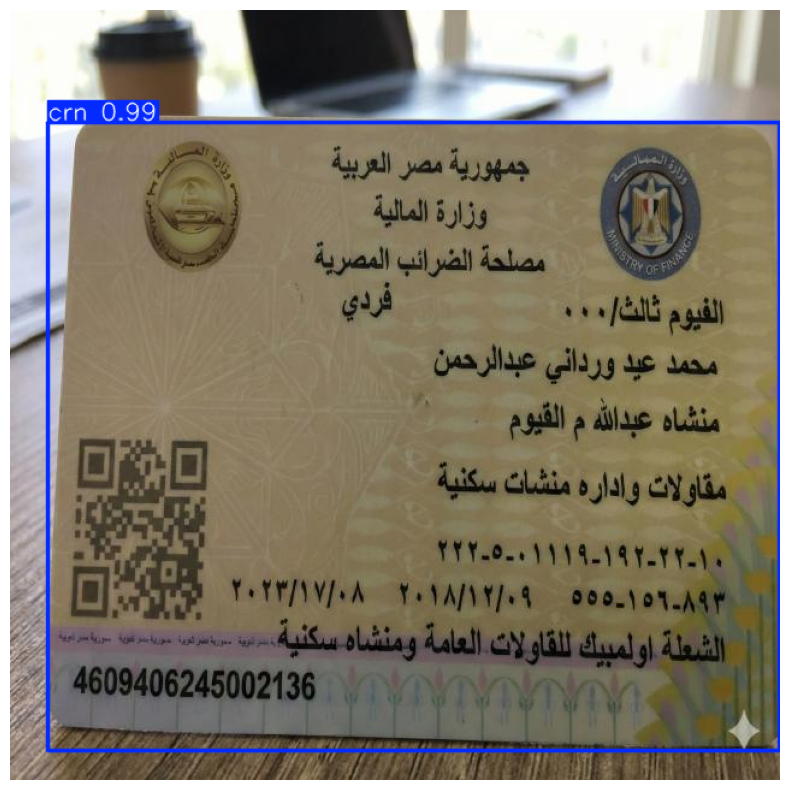

In [1]:
results = model_crop.predict(source=test_image_path, conf=0.25)
result_image = results[0].plot()

plt.figure(figsize=(10, 10))
plt.imshow(result_image[..., ::-1])
plt.axis('off')
plt.title("Crop Model Detection")
plt.show()

In [1]:
for box in results[0].boxes:
    class_id = int(box.cls[0])
    class_name = model_crop.names[class_id]
    confidence = float(box.conf[0])
    print(f"Class: {class_name} | confidence: {confidence:.3f}")

الكلاس: crn | الثقة: 0.987 | الإحداثيات: [31.34814453125, 93.8587646484375, 639.9622802734375, 615.4691162109375]


نوع الكارت المكتشف: crn
أبعاد الصورة المقصوصة: (577, 639, 3)


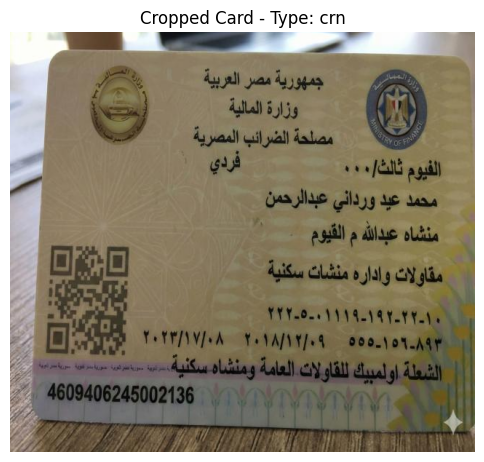

In [1]:
cropped_img, card_type = crop_card(test_image_path, model_crop)

if cropped_img is not None:
    print(f"Detected card type: {card_type}")
    print(f"Cropped image shape: {cropped_img.shape}")
    plt.figure(figsize=(6, 6))
    plt.imshow(cropped_img[..., ::-1])
    plt.axis('off')
    plt.title(f"Cropped Card - {card_type}")
    plt.show()